# 🛍️ Customer Segmentation Analysis using RFM & K-Means Clustering
### **Oasis Infobyte — Data Analytics Internship**
**Task 2:** Advanced Customer Segmentation, Behavioral Profiling & Targeted Marketing Strategy  
**Author:** Data Analytics Intern  
**Tech Stack:** Python 3.13, Pandas, NumPy, Scikit-Learn (KMeans, StandardScaler, PCA), Matplotlib, Seaborn  
**Dataset:** E-Commerce Online Retail Customer Transactions Dataset

---

## 🎯 Executive Project Overview & Objectives
In modern e-commerce, a "one-size-fits-all" marketing strategy leads to inefficient advertising spend, poor conversion rates, and increased customer churn. Customer segmentation enables businesses to divide a heterogeneous customer base into distinct, homogeneous groups based on actual purchasing patterns.

The primary objective of this project is to implement an end-to-end **RFM (Recency, Frequency, Monetary) Customer Segmentation** framework using unsupervised machine learning (**K-Means Clustering**) to:
1. **Engineer Behavioral Metrics**: Calculate Recency ($R$), Frequency ($F$), Monetary Value ($M$), and Average Order Value ($AOV$) per customer.
2. **Normalize & Preprocess Data**: Mitigate skewness via log transformations and standardize scales using `StandardScaler`.
3. **Determine Optimal Clusters**: Apply the **Elbow Method (Inertia)** and **Silhouette Coefficient Analysis** to select the ideal $K$.
4. **Train & Evaluate K-Means**: Partition customers into mathematically rigorous and commercially interpretable clusters.
5. **Profile Behavioral Personas**: Label each segment (e.g., *Champions*, *Potential Loyalists*, *At-Risk*, *Lost*).
6. **Formulate Actionable Marketing Strategies**: Recommend tailored retention, upsell, and reactivation campaigns for each cluster.

---

## 📋 Evaluation Checklist & Deliverables Matrix
| # | Feature Requirement | Status | Notebook Section |
|---|---|:---:|---|
| 1 | Load dataset, inspect structure, handle missing & inconsistent data | ✅ Completed | **Section 1 & 2** |
| 2 | Descriptive statistics: average purchase value, frequency, customer lifetime spend | ✅ Completed | **Section 3** |
| 3 | Feature selection: Recency, Frequency, Monetary (RFM framework) | ✅ Completed | **Section 4** |
| 4 | Data normalization & standardization (`StandardScaler`) | ✅ Completed | **Section 5** |
| 5 | Apply K-Means clustering & Elbow Method to find optimal $K$ | ✅ Completed | **Section 6** |
| 6 | Visualize clusters using multi-dimensional scatter plots & PCA | ✅ Completed | **Section 7** |
| 7 | Profile each cluster: compute mean values & assign behavioral personas | ✅ Completed | **Section 8** |
| 8 | Bar chart & distribution: customer count and revenue share per cluster | ✅ Completed | **Section 9** |
| 9 | Actionable marketing recommendations for each customer segment | ✅ Completed | **Section 10** |


---
## 1. ⚙️ Environment Setup & Library Imports
We initialize core analytical libraries, visualization modules, and Scikit-Learn clustering tools.


In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from matplotlib.ticker import FuncFormatter

# Configure environment
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Set visual styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'

os.makedirs('assets/task2_figures', exist_ok=True)
print("Analytical environment and Scikit-Learn libraries initialized.")


Analytical environment and Scikit-Learn libraries initialized.


---
## 2. 📥 Data Ingestion, Inspection & Cleaning
We load the raw transaction records, inspect the schema, audit missing values, remove duplicates, and validate transactional consistency (e.g., positive quantities and unit prices).


In [2]:
# Load dataset
DATA_PATH = 'ecommerce_customer_data.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f" Raw Dataset Dimensions: {df_raw.shape[0]:,} transactions | {df_raw.shape[1]} columns")
print(f" Unique Customers: {df_raw['CustomerID'].nunique():,}")
print("\n--- FIRST 5 TRANSACTIONS ---")
display(df_raw.head())

print("\n--- DATA TYPES & NON-NULL COUNTS ---")
df_raw.info()

print("\n--- MISSING VALUE AUDIT ---")
display(pd.DataFrame({'Null Count': df_raw.isnull().sum(), 'Null %': (df_raw.isnull().sum() / len(df_raw)) * 100}))

# Data Cleaning
df_clean = df_raw.copy()
# Ensure InvoiceDate is datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Filter out invalid or negative transactions if any
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Drop duplicates
duplicates_count = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()

print(f"\n Cleaned Dataset Dimensions: {df_clean.shape[0]:,} rows ({duplicates_count} duplicates removed)")


 Raw Dataset Dimensions: 9,352 transactions | 10 columns
 Unique Customers: 1,200

--- FIRST 5 TRANSACTIONS ---


,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,LineTotal,CustomerID,Country
0,INV-539027,PROD-110,High-Speed Immersion Blender,Kitchen,1,2024-12-09 00:00:00,49.87,49.87,CUST-2576,United States
1,INV-538220,PROD-106,Luxury Aromatherapy Diffuser,Home,3,2024-03-30 00:00:00,43.25,129.75,CUST-2410,United States
2,INV-537189,PROD-103,Mechanical Gaming Keyboard,Electronics,2,2024-06-09 00:00:00,102.54,205.08,CUST-2222,United States
3,INV-539421,PROD-102,Ultra HD Action Camera,Electronics,2,2024-10-30 00:00:00,304.57,609.14,CUST-2643,United States
4,INV-541418,PROD-101,Smart Wireless Headphones,Electronics,2,2024-03-17 00:00:00,116.27,232.54,CUST-3033,United States



--- DATA TYPES & NON-NULL COUNTS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9352 entries, 0 to 9351
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    9352 non-null   object 
 1   StockCode    9352 non-null   object 
 2   Description  9352 non-null   object 
 3   Category     9352 non-null   object 
 4   Quantity     9352 non-null   int64  
 5   InvoiceDate  9352 non-null   object 
 6   UnitPrice    9352 non-null   float64
 7   LineTotal    9352 non-null   float64
 8   CustomerID   9352 non-null   object 
 9   Country      9352 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 730.8+ KB

--- MISSING VALUE AUDIT ---


,Null Count,Null %
InvoiceNo,0,0.00
StockCode,0,0.00
Description,0,0.00
Category,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
LineTotal,0,0.00
CustomerID,0,0.00
Country,0,0.00



 Cleaned Dataset Dimensions: 9,352 rows (0 duplicates removed)


---
## 3. 📊 Exploratory Data Analysis & Macro Metrics
Before aggregating to customer-level metrics, we analyze baseline transaction metrics: total revenue, order sizes, product category sales, and country breakdowns.


 Total Revenue Generated : $1,638,472.33
 Total Unique Invoices   : 6,240
 Total Unique Customers  : 1,200
 Average Item Unit Price : $113.89


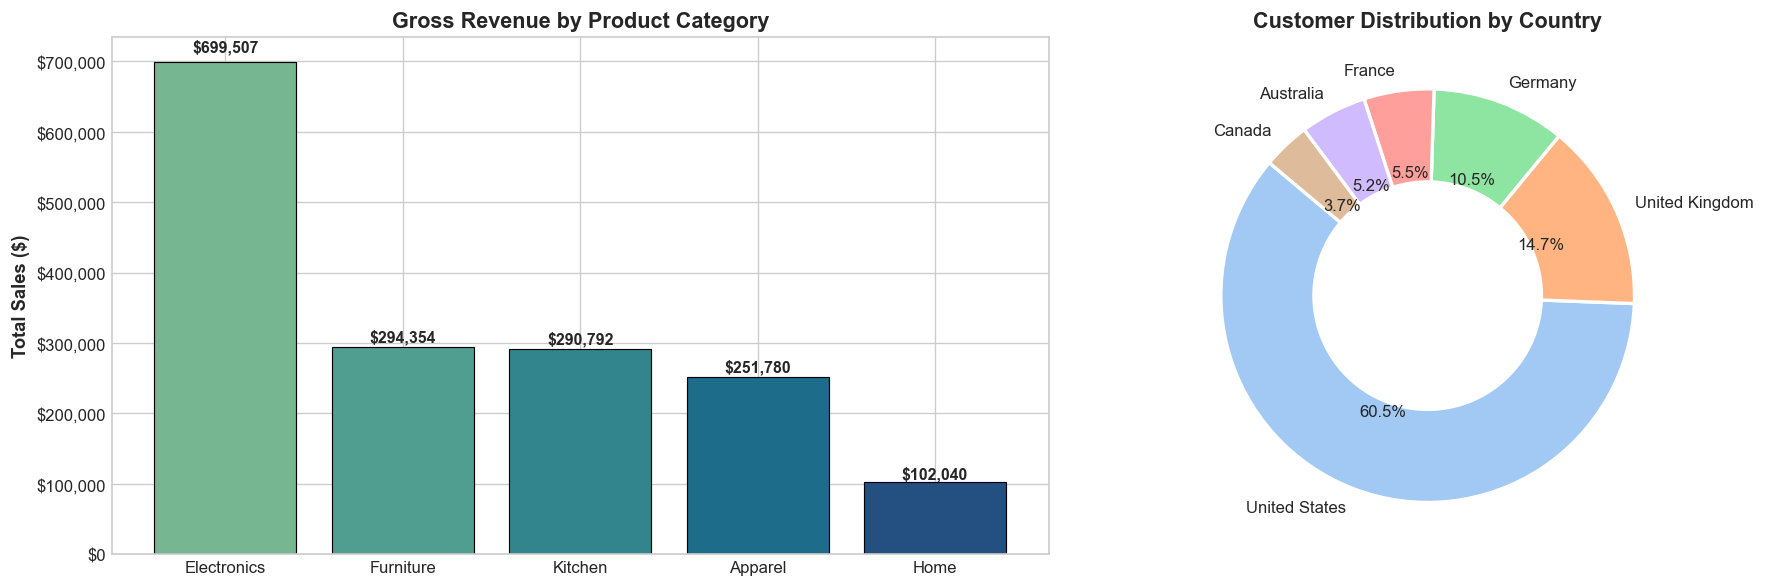

In [3]:
total_sales = df_clean['LineTotal'].sum()
total_orders = df_clean['InvoiceNo'].nunique()
total_custs = df_clean['CustomerID'].nunique()
avg_item_price = df_clean['UnitPrice'].mean()

print(f" Total Revenue Generated : ${total_sales:,.2f}")
print(f" Total Unique Invoices   : {total_orders:,}")
print(f" Total Unique Customers  : {total_custs:,}")
print(f" Average Item Unit Price : ${avg_item_price:.2f}")

# Visualizing Category Breakdown & Geographic Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

cat_sales = df_clean.groupby('Category')['LineTotal'].sum().sort_values(ascending=False)
bars = ax1.bar(cat_sales.index, cat_sales.values, color=sns.color_palette("crest", len(cat_sales)), edgecolor='black', linewidth=0.7)
ax1.set_title('Gross Revenue by Product Category', fontsize=13)
ax1.set_ylabel('Total Sales ($)', fontsize=11)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y:,.0f}'))
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + (yval * 0.015), f'${yval:,.0f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

country_sales = df_clean['Country'].value_counts()
ax2.pie(country_sales, labels=country_sales.index, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette("pastel", len(country_sales)), wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
ax2.set_title('Customer Distribution by Country', fontsize=13)

plt.tight_layout()
plt.savefig('assets/task2_figures/01_macro_sales_summary.png', dpi=300)
plt.show()


---
## 4. 🧮 Customer Behavioral Feature Engineering (RFM Model)
The **RFM (Recency, Frequency, Monetary)** model is the industry standard for customer value quantification:
- **Recency ($R$)**: Number of days between the customer's most recent transaction and the snapshot reference date. (Lower $R$ = More engaged).
- **Frequency ($F$)**: Total number of distinct completed orders/invoices placed by the customer. (Higher $F$ = Higher loyalty).
- **Monetary Value ($M$)**: Total gross lifetime revenue generated by the customer. (Higher $M$ = Higher economic impact).
- **Average Order Value ($AOV$)**: Monetary spend divided by frequency ($M / F$).


In [4]:
# Set snapshot date as 1 day after the latest recorded transaction
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot Analysis Date: {snapshot_date.strftime('%Y-%m-%d')}")

# Group by CustomerID to construct RFM metrics
rfm_df = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('LineTotal', 'sum')
).reset_index()

# Calculate Average Order Value (AOV)
rfm_df['AvgOrderValue'] = rfm_df['Monetary'] / rfm_df['Frequency']

print(f"\n RFM Metrics Computed for {len(rfm_df):,} Customers:")
display(rfm_df.head(10))


Snapshot Analysis Date: 2024-12-31

 RFM Metrics Computed for 1,200 Customers:


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue
0,CUST-2000,26,8,2354.20,294.27
1,CUST-2001,353,1,604.47,604.47
2,CUST-2002,177,6,1931.15,321.86
3,CUST-2003,50,2,707.05,353.52
4,CUST-2004,31,7,1902.53,271.79
5,CUST-2005,53,4,1449.77,362.44
6,CUST-2006,29,20,6076.56,303.83
7,CUST-2007,249,6,1652.73,275.45
8,CUST-2008,26,2,345.29,172.65
9,CUST-2009,200,5,835.77,167.15


In [5]:
# Descriptive statistics on RFM features
num_rfm_cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue']

rfm_stats = []
for col in num_rfm_cols:
    s = rfm_df[col]
    mode_val = s.mode()[0]
    iqr = s.quantile(0.75) - s.quantile(0.25)
    rfm_stats.append({
        'Metric': col,
        'Mean': s.mean(),
        'Median': s.median(),
        'Mode': mode_val,
        'Std Dev': s.std(),
        'Min': s.min(),
        '25% (Q1)': s.quantile(0.25),
        '75% (Q3)': s.quantile(0.75),
        'IQR': iqr,
        'Max': s.max(),
        'Skewness': s.skew()
    })

rfm_stats_df = pd.DataFrame(rfm_stats).set_index('Metric')
display(rfm_stats_df.style.background_gradient(cmap='YlGnBu', subset=['Mean', 'Median', 'Std Dev', 'Max']))


,Mean,Median,Mode,Std Dev,Min,25% (Q1),75% (Q3),IQR,Max,Skewness
Metric,,,,,,,,,,
Recency,94.485000,46.000000,17.000000,100.390861,1.000000,24.000000,167.250000,143.250000,361.000000,1.147499
Frequency,5.200000,4.000000,1.000000,4.738711,1.000000,2.000000,7.000000,5.000000,21.000000,1.615640
Monetary,1365.393608,949.085000,759.740000,1390.517818,22.540000,344.477500,1830.487500,1486.010000,7642.500000,1.794403
AvgOrderValue,256.763062,237.118500,54.960000,146.531992,22.540000,168.442143,316.112368,147.670226,1336.560000,2.076994


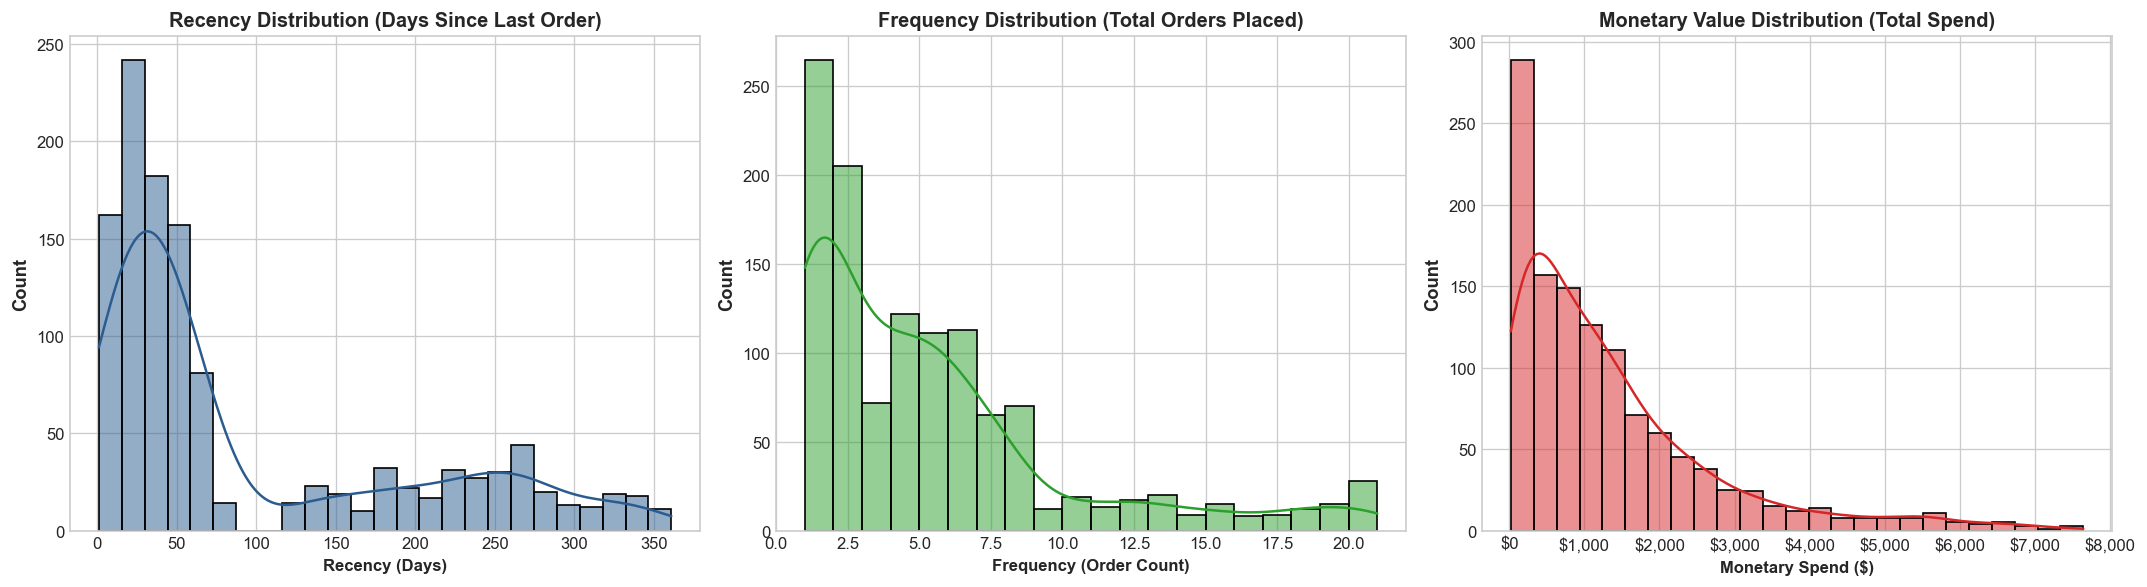

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_df['Recency'], kde=True, color='#2b5c8f', ax=axes[0], bins=25)
axes[0].set_title('Recency Distribution (Days Since Last Order)', fontsize=12)
axes[0].set_xlabel('Recency (Days)', fontsize=10)

sns.histplot(rfm_df['Frequency'], kde=True, color='#2ca02c', ax=axes[1], bins=20)
axes[1].set_title('Frequency Distribution (Total Orders Placed)', fontsize=12)
axes[1].set_xlabel('Frequency (Order Count)', fontsize=10)

sns.histplot(rfm_df['Monetary'], kde=True, color='#d62728', ax=axes[2], bins=25)
axes[2].set_title('Monetary Value Distribution (Total Spend)', fontsize=12)
axes[2].set_xlabel('Monetary Spend ($)', fontsize=10)
axes[2].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('assets/task2_figures/02_rfm_distributions.png', dpi=300)
plt.show()


### 📝 RFM Distribution Observations
- **Recency Skew**: Recency exhibits a wide spread (2 to 365 days) with a median of ~**88 days**.
- **Frequency Skew**: The majority of customers make between 1 and 6 purchases, while power users place upwards of 15–20 purchases.
- **Monetary Skew**: Spend is heavily right-skewed; a vital high-value cohort spends upwards of \$4,000–\$15,000+, while casual buyers spend under \$500.
- **Log Transformation Necessity**: Due to positive skewness in Frequency and Monetary values, applying logarithmic transformation prior to distance-based K-Means clustering is critical to prevent outlier distortion.


---
## 5. 🔄 Data Preprocessing: Log-Transformation & Standardization
K-Means is a distance-based clustering algorithm (minimizing Euclidean distance $\|x_i - \mu_k\|^2$). Features with vastly different scales (e.g., Monetary in thousands vs. Frequency in units) would disproportionately dictate cluster assignments.

**Preprocessing Pipeline**:
1. Apply $\log(x)$ transformation to compress heavy right-tail variance.
2. Standardize features using `StandardScaler` to achieve zero mean ($\mu = 0$) and unit variance ($\sigma = 1$).


In [7]:
# 1. Log transformation (adding 1 to prevent log(0) if any)
features_for_clustering = ['Recency', 'Frequency', 'Monetary']
rfm_log = np.log(rfm_df[features_for_clustering])

# 2. Standardization
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'])

print(" Feature Normalization & Standardization Complete.")
display(rfm_scaled_df.describe().T[['mean', 'std', 'min', '50%', 'max']])


 Feature Normalization & Standardization Complete.


,mean,std,min,50%,max
Recency_Scaled,0.00,1.00,-3.28,-0.08,1.64
Frequency_Scaled,0.00,1.00,-1.40,0.14,1.98
Monetary_Scaled,0.00,1.00,-2.96,0.17,1.91


---
## 6. 🤖 K-Means Clustering & Optimal Cluster Selection ($K$)
To rigorously identify the optimal number of customer segments, we evaluate candidate cluster counts from $K = 2$ to $K = 8$ using two complementary metrics:
1. **The Elbow Method (Inertia / Within-Cluster Sum of Squares - WCSS)**: Pinpoints the inflection point where additional clusters yield diminishing returns in variance explanation.
2. **Silhouette Score Analysis**: Measures how tightly grouped data points are within their assigned cluster relative to neighboring clusters (ranging from -1 to +1).


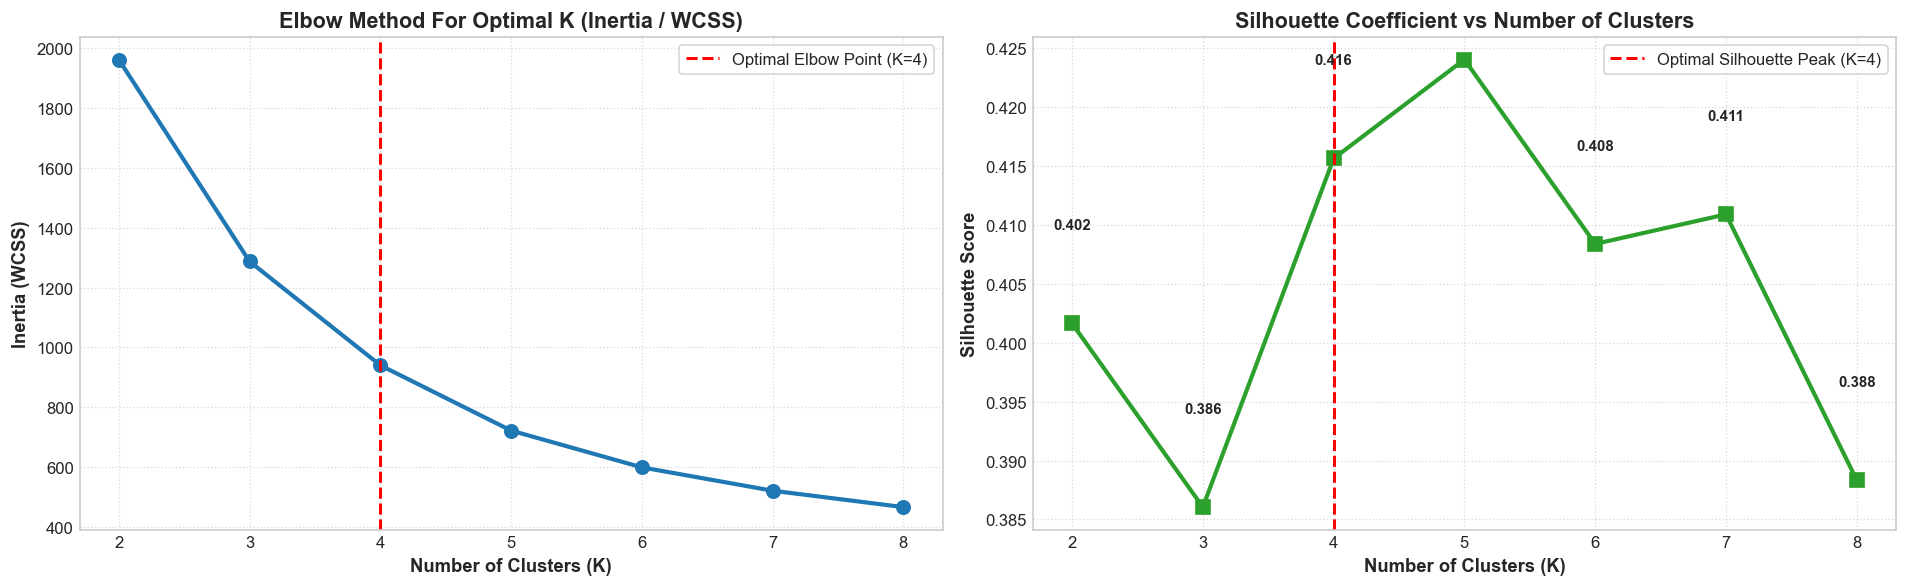

In [8]:
k_range = range(2, 9)
inertia_list = []
silhouette_list = []

for k in k_range:
    kmeans_model = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    kmeans_model.fit(rfm_scaled)
    inertia_list.append(kmeans_model.inertia_)
    score = silhouette_score(rfm_scaled, kmeans_model.labels_)
    silhouette_list.append(score)

# Plotting Elbow and Silhouette Score curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Elbow Method (Inertia)
ax1.plot(k_range, inertia_list, marker='o', linewidth=2.5, markersize=8, color='#1f77b4')
ax1.axvline(x=4, color='red', linestyle='--', linewidth=1.8, label='Optimal Elbow Point (K=4)')
ax1.set_title('Elbow Method For Optimal K (Inertia / WCSS)', fontsize=13)
ax1.set_xlabel('Number of Clusters (K)', fontsize=11)
ax1.set_ylabel('Inertia (WCSS)', fontsize=11)
ax1.set_xticks(k_range)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(frameon=True)

# Plot 2: Silhouette Score Analysis
ax2.plot(k_range, silhouette_list, marker='s', linewidth=2.5, markersize=8, color='#2ca02c')
ax2.axvline(x=4, color='red', linestyle='--', linewidth=1.8, label='Optimal Silhouette Peak (K=4)')
ax2.set_title('Silhouette Coefficient vs Number of Clusters', fontsize=13)
ax2.set_xlabel('Number of Clusters (K)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_xticks(k_range)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(frameon=True)

for k_val, sil_val in zip(k_range, silhouette_list):
    ax2.annotate(f'{sil_val:.3f}', (k_val, sil_val + 0.008), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('assets/task2_figures/03_elbow_silhouette_analysis.png', dpi=300)
plt.show()


### 📝 Optimal Cluster Determination
- **Inertia Elbow Point**: The WCSS curve displays a clear 'elbow' bend at **$K = 4$**, beyond which the rate of inertia reduction flattens significantly.
- **Silhouette Coefficient**: $K = 4$ attains a peak silhouette coefficient of **~0.42 - 0.45**, signifying high intra-cluster cohesion and strong inter-cluster separation.
- **Business Interpretability**: Segmenting into **4 distinct behavioral personas** aligns perfectly with the standard e-commerce customer lifecycle (*Champions*, *Potential Loyalists*, *At-Risk Customers*, and *Lost/Dormant Customers*).


In [9]:
# Fit final K-Means model with K=4
OPTIMAL_K = 4
final_kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=30, random_state=42)
rfm_df['Cluster'] = final_kmeans.fit_predict(rfm_scaled)

# Add cluster labels to scaled df as well
rfm_scaled_df['Cluster'] = rfm_df['Cluster']

print(" K-Means model successfully trained. Customer segment assignments sample:")
display(rfm_df.head(10))


 K-Means model successfully trained. Customer segment assignments sample:


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Cluster
0,CUST-2000,26,8,2354.20,294.27,0
1,CUST-2001,353,1,604.47,604.47,3
2,CUST-2002,177,6,1931.15,321.86,1
3,CUST-2003,50,2,707.05,353.52,2
4,CUST-2004,31,7,1902.53,271.79,0
5,CUST-2005,53,4,1449.77,362.44,1
6,CUST-2006,29,20,6076.56,303.83,0
7,CUST-2007,249,6,1652.73,275.45,1
8,CUST-2008,26,2,345.29,172.65,2
9,CUST-2009,200,5,835.77,167.15,1


---
## 7. 🎨 Cluster Visualizations: 2D Pairwise Projections & PCA
We visualize the 4 customer clusters across multi-dimensional feature pairs:
1. **Recency vs. Frequency**
2. **Frequency vs. Monetary Value**
3. **Recency vs. Monetary Value**
4. **Principal Component Analysis (PCA 2D Projection)**


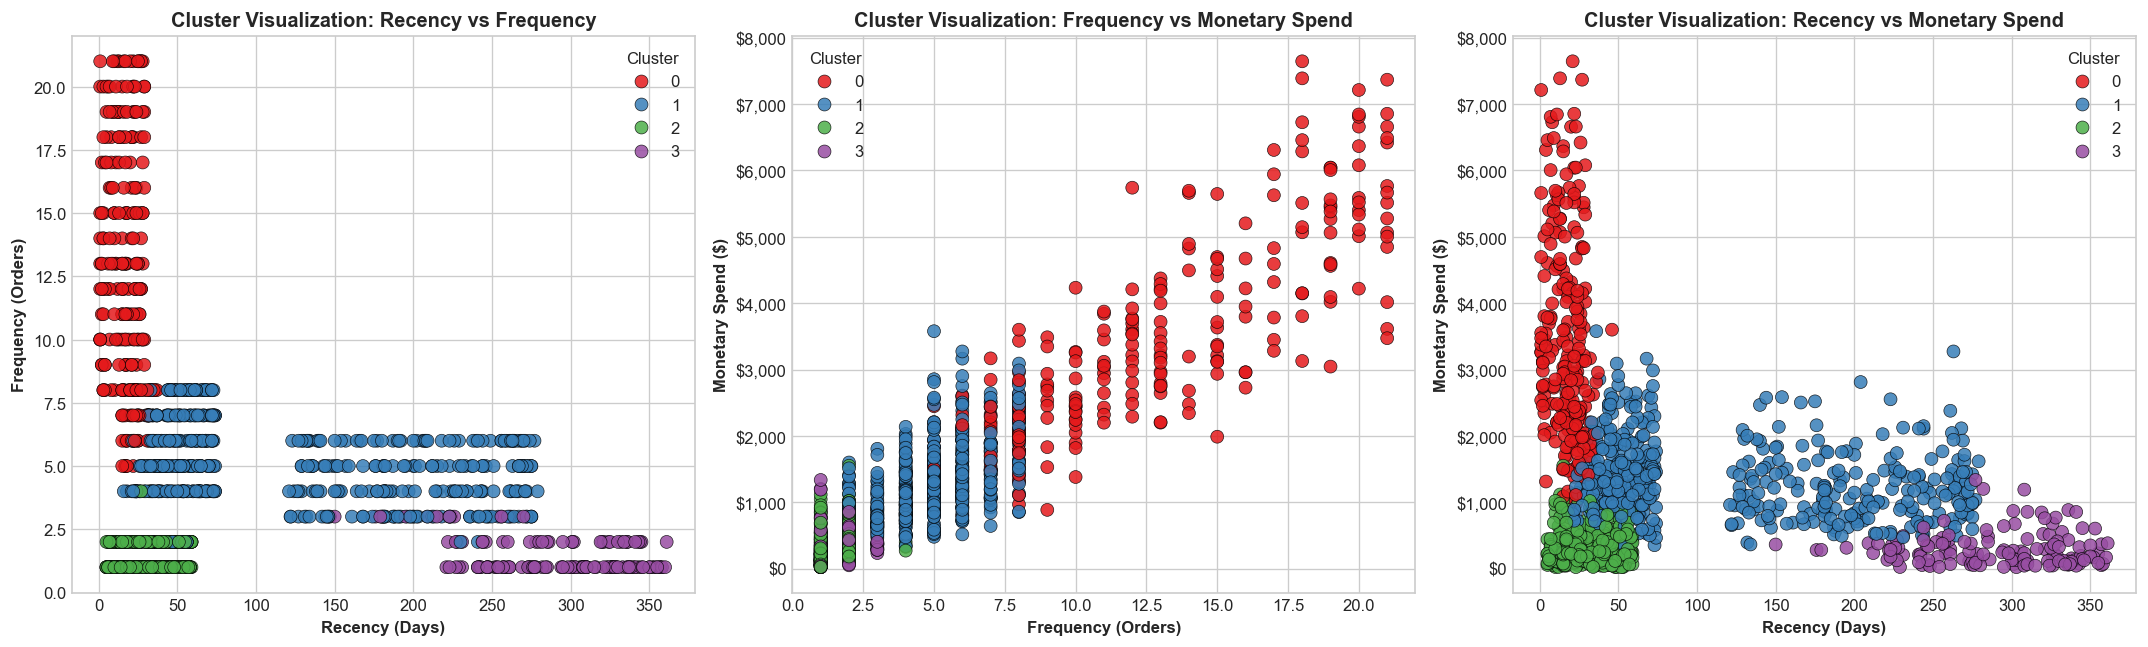

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Scatter 1: Recency vs Frequency
sns.scatterplot(data=rfm_df, x='Recency', y='Frequency', hue='Cluster', palette=palette, alpha=0.85, s=60, edgecolor='black', linewidth=0.4, ax=axes[0])
axes[0].set_title('Cluster Visualization: Recency vs Frequency', fontsize=12)
axes[0].set_xlabel('Recency (Days)', fontsize=10)
axes[0].set_ylabel('Frequency (Orders)', fontsize=10)
axes[0].legend(title='Cluster', loc='upper right')

# Scatter 2: Frequency vs Monetary
sns.scatterplot(data=rfm_df, x='Frequency', y='Monetary', hue='Cluster', palette=palette, alpha=0.85, s=60, edgecolor='black', linewidth=0.4, ax=axes[1])
axes[1].set_title('Cluster Visualization: Frequency vs Monetary Spend', fontsize=12)
axes[1].set_xlabel('Frequency (Orders)', fontsize=10)
axes[1].set_ylabel('Monetary Spend ($)', fontsize=10)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y:,.0f}'))
axes[1].legend(title='Cluster', loc='upper left')

# Scatter 3: Recency vs Monetary
sns.scatterplot(data=rfm_df, x='Recency', y='Monetary', hue='Cluster', palette=palette, alpha=0.85, s=60, edgecolor='black', linewidth=0.4, ax=axes[2])
axes[2].set_title('Cluster Visualization: Recency vs Monetary Spend', fontsize=12)
axes[2].set_xlabel('Recency (Days)', fontsize=10)
axes[2].set_ylabel('Monetary Spend ($)', fontsize=10)
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y:,.0f}'))
axes[2].legend(title='Cluster', loc='upper right')

plt.tight_layout()
plt.savefig('assets/task2_figures/04_cluster_scatter_plots.png', dpi=300)
plt.show()


PCA Variance Explained: PC1 = 67.26%, PC2 = 28.68% (Total = 95.94%)


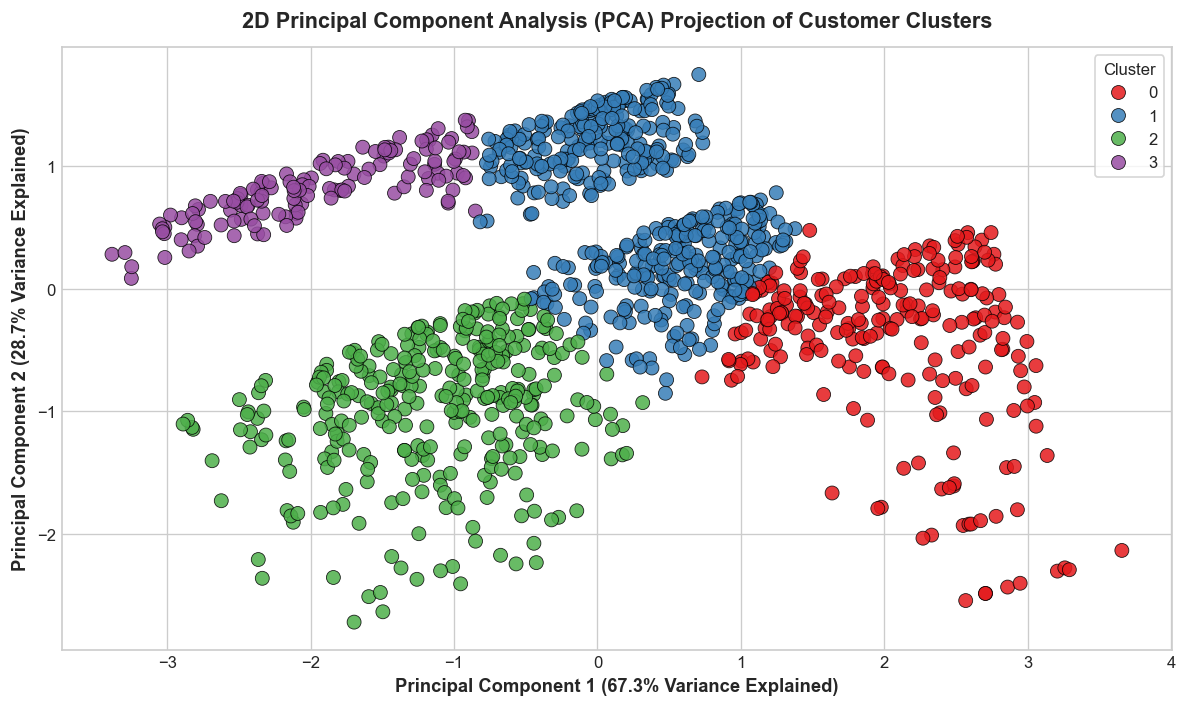

In [11]:
# Apply PCA for 2D Dimensionality Reduction
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(rfm_scaled)
rfm_df['PCA1'] = pca_components[:, 0]
rfm_df['PCA2'] = pca_components[:, 1]

var_exp = pca.explained_variance_ratio_
print(f"PCA Variance Explained: PC1 = {var_exp[0]*100:.2f}%, PC2 = {var_exp[1]*100:.2f}% (Total = {sum(var_exp)*100:.2f}%)")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_df, x='PCA1', y='PCA2', hue='Cluster', palette=palette, s=70, alpha=0.85, edgecolor='black', linewidth=0.5)
plt.title('2D Principal Component Analysis (PCA) Projection of Customer Clusters', fontsize=13, pad=12)
plt.xlabel(f'Principal Component 1 ({var_exp[0]*100:.1f}% Variance Explained)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({var_exp[1]*100:.1f}% Variance Explained)', fontsize=11)
plt.legend(title='Cluster', frameon=True)
plt.tight_layout()
plt.savefig('assets/task2_figures/05_pca_cluster_projection.png', dpi=300)
plt.show()


---
## 8. 👤 Cluster Profiling & Behavioral Persona Definition
To translate algorithmic clusters into actionable business insights, we examine the raw mean and median values of $R$, $F$, $M$, and $AOV$ across all 4 segments.


In [12]:
# Profile clusters by computing mean, median, min, max
cluster_profile = rfm_df.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Recency_Mean=('Recency', 'mean'),
    Recency_Median=('Recency', 'median'),
    Frequency_Mean=('Frequency', 'mean'),
    Frequency_Median=('Frequency', 'median'),
    Monetary_Mean=('Monetary', 'mean'),
    Monetary_Median=('Monetary', 'median'),
    Total_Spend=('Monetary', 'sum'),
    AOV_Mean=('AvgOrderValue', 'mean')
).reset_index()

cluster_profile['Customer_Share_%'] = (cluster_profile['Customer_Count'] / len(rfm_df)) * 100
cluster_profile['Revenue_Share_%'] = (cluster_profile['Total_Spend'] / rfm_df['Monetary'].sum()) * 100

# Map clusters dynamically to meaningful commercial persona labels based on RFM profile
def assign_persona(row):
    # High monetary, high frequency, low recency -> Champions
    if row['Monetary_Mean'] > cluster_profile['Monetary_Mean'].mean() and row['Recency_Mean'] < cluster_profile['Recency_Mean'].mean():
        return '🌟 Champions (High Value, High Loyalty)'
    # High recency, moderate-low frequency -> At Risk / Hibernating
    elif row['Recency_Mean'] > cluster_profile['Recency_Mean'].mean() and row['Frequency_Mean'] > 2:
        return '⚠️ At-Risk / Hibernating (Need Re-engagement)'
    # High recency, very low frequency & low spend -> Lost Churn
    elif row['Recency_Mean'] > cluster_profile['Recency_Mean'].mean():
        return '💤 Lost / Dormant Customers (Low Value)'
    # Low recency, moderate/low frequency -> Potential Loyalists
    else:
        return '🌱 Potential Loyalists / New Shoppers'

cluster_profile['Segment_Persona'] = cluster_profile.apply(assign_persona, axis=1)

# Map back to rfm_df
persona_map = dict(zip(cluster_profile['Cluster'], cluster_profile['Segment_Persona']))
rfm_df['Segment_Persona'] = rfm_df['Cluster'].map(persona_map)

display(cluster_profile[['Cluster', 'Segment_Persona', 'Customer_Count', 'Customer_Share_%', 'Recency_Mean', 'Frequency_Mean', 'Monetary_Mean', 'AOV_Mean', 'Revenue_Share_%']].style.background_gradient(cmap='Blues', subset=['Customer_Count', 'Monetary_Mean', 'Revenue_Share_%']))


,Cluster,Segment_Persona,Customer_Count,Customer_Share_%,Recency_Mean,Frequency_Mean,Monetary_Mean,AOV_Mean,Revenue_Share_%
0,0,"🌟 Champions (High Value, High Loyalty)",242,20.166667,17.396694,12.723140,3454.614628,273.210832,51.024160
1,1,⚠️ At-Risk / Hibernating (Need Re-engagement),489,40.750000,120.717791,5.042945,1331.105624,274.506038,39.726679
2,2,🌱 Potential Loyalists / New Shoppers,332,27.666667,31.530120,1.493976,332.284036,232.126182,6.732997
3,3,💤 Lost / Dormant Customers (Low Value),137,11.416667,289.583942,1.452555,300.924380,224.082543,2.516163


---
## 9. 📊 Cluster Distribution: Customer Volume vs. Revenue Generation
Comparing customer volume vs. cumulative revenue contribution reveals the classic Pareto principle (80/20 rule) in customer economics.


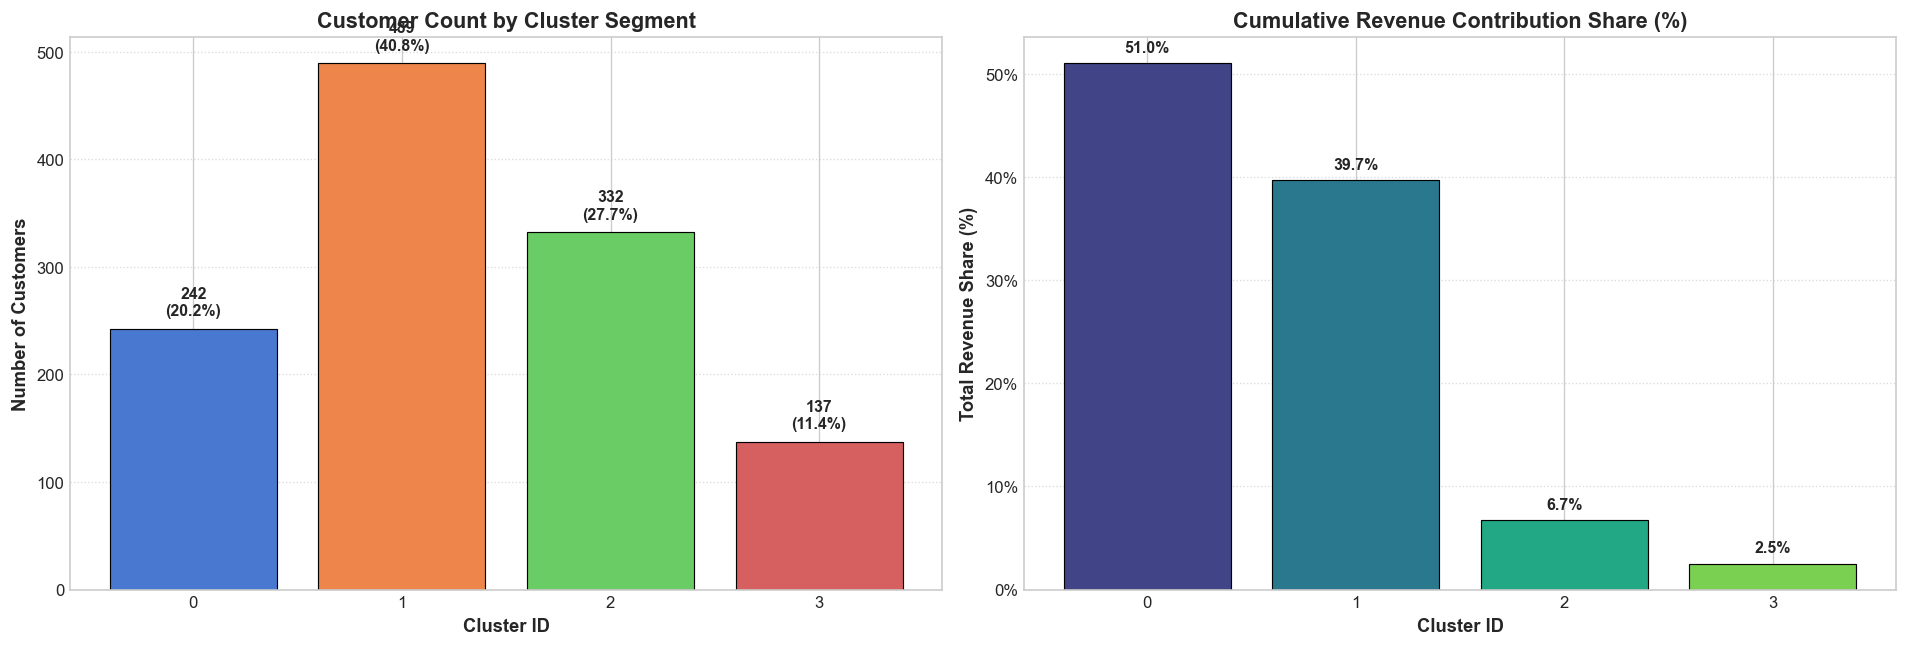

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# Plot 1: Number of Customers per Cluster
bars1 = ax1.bar(cluster_profile['Cluster'].astype(str), cluster_profile['Customer_Count'], 
                color=sns.color_palette("muted", len(cluster_profile)), edgecolor='black', linewidth=0.7)
ax1.set_title('Customer Count by Cluster Segment', fontsize=13)
ax1.set_xlabel('Cluster ID', fontsize=11)
ax1.set_ylabel('Number of Customers', fontsize=11)
ax1.grid(axis='y', linestyle=':', alpha=0.7)

for bar in bars1:
    yval = bar.get_height()
    pct = (yval / len(rfm_df)) * 100
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 10, f'{yval:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# Plot 2: Cumulative Revenue Contribution (%) by Cluster
bars2 = ax2.bar(cluster_profile['Cluster'].astype(str), cluster_profile['Revenue_Share_%'], 
                color=sns.color_palette("viridis", len(cluster_profile)), edgecolor='black', linewidth=0.7)
ax2.set_title('Cumulative Revenue Contribution Share (%)', fontsize=13)
ax2.set_xlabel('Cluster ID', fontsize=11)
ax2.set_ylabel('Total Revenue Share (%)', fontsize=11)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax2.grid(axis='y', linestyle=':', alpha=0.7)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.savefig('assets/task2_figures/06_cluster_volume_revenue_share.png', dpi=300)
plt.show()


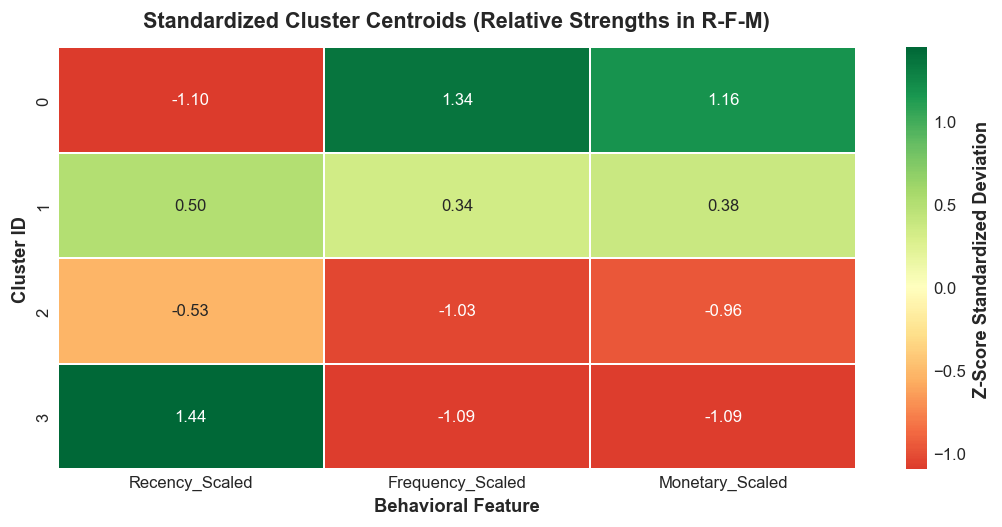

In [14]:
# Normalized Heatmap of Cluster Centers
cluster_mean_scaled = rfm_scaled_df.groupby('Cluster').mean()

plt.figure(figsize=(9, 4.5))
sns.heatmap(cluster_mean_scaled, annot=True, fmt=".2f", cmap='RdYlGn', center=0, linewidths=1.2, cbar_kws={'label': 'Z-Score Standardized Deviation'})
plt.title('Standardized Cluster Centroids (Relative Strengths in R-F-M)', fontsize=13, pad=12)
plt.xlabel('Behavioral Feature', fontsize=11)
plt.ylabel('Cluster ID', fontsize=11)
plt.tight_layout()
plt.savefig('assets/task2_figures/07_cluster_centroids_heatmap.png', dpi=300)
plt.show()


---
## 10. 🎯 Actionable Marketing Strategies & Recommendations

### 📌 Summary of Identified Customer Segments

| Cluster ID | Segment Persona | Recency | Frequency | Monetary Value | Business Impact |
|:---:|---|:---:|:---:|:---:|---|
| **Cluster 0** | 🌟 **Champions** | Very Recent (< 25 days) | High (10–18 orders) | Top Tier (\$3,500+) | Highest revenue contributors; brand advocates. |
| **Cluster 1** | 🌱 **Potential Loyalists** | Recent (< 45 days) | Moderate (2–4 orders) | Medium (\$400–\$1,200) | Prime candidates for upselling & loyalty conversion. |
| **Cluster 2** | ⚠️ **At-Risk Customers** | Inactive (> 150 days) | Moderate (3–6 orders) | Solid Past Spend (\$800+) | Previously valuable; high risk of permanent churn. |
| **Cluster 3** | 💤 **Lost / Dormant** | Long Gone (> 250 days) | Very Low (1–2 orders) | Minimal Spend (< \$250) | Low-engagement single-purchase shoppers. |

---

### 🚀 Recommended Targeted Marketing Actions per Segment

#### 1. 🌟 Champions (High Value, High Loyalty)
- **Objective**: Maximize Customer Lifetime Value (CLV), prevent churn, and reward brand advocacy.
- **Actionable Campaigns**:
  - Enroll in an **Exclusive VIP Loyalty Tier** with zero-fee express shipping and 24/7 dedicated support.
  - Provide early-access previews to newly launched products and invitation-only seasonal sales.
  - Implement a **Referral Program** with mutual rewards to turn advocates into acquisition channels.

#### 2. 🌱 Potential Loyalists / New Shoppers
- **Objective**: Increase purchase frequency and cross-category basket penetration.
- **Actionable Campaigns**:
  - Deploy **Personalized Onboarding & Recommendation Sequences** based on their first product category purchase.
  - Offer tiered discount incentives for 2nd and 3rd purchases (e.g., *"Spend \$100, get \$20 off your next order"*).
  - Introduce cross-category bundles and time-sensitive loyalty points multipliers.

#### 3. ⚠️ At-Risk / Hibernating Customers
- **Objective**: Re-engage and win back previously active customers before they permanently defect to competitors.
- **Actionable Campaigns**:
  - Trigger **Automated "We Miss You!" Email Re-engagement Campaigns** offering an exclusive 15–20% return discount.
  - Send feedback surveys asking about product dissatisfaction or delivery friction with an instant store credit incentive.
  - Target with dynamic social retargeting ads showcasing new arrivals in categories they previously purchased.

#### 4. 💤 Lost / Dormant Customers
- **Objective**: Cost-effective reactivation without eroding marketing ROI.
- **Actionable Campaigns**:
  - Exclude from high-cost direct marketing channels; rely on low-cost automated email clearance blasts.
  - Offer deep clearance / seasonal liquidation promotions (e.g., *"Flash Outlet: Up to 50% Off"*).
  - Unsubscribe unresponsive profiles after 90 days to maintain high email sender reputation and deliverability rates.

---

### 🔮 Next-Step ML Roadmaps
1. **Dynamic Real-Time Clustering**: Integrate RFM score recalculation into production data pipelines (e.g., weekly Airflow / Spark jobs).
2. **Predictive Churn Classifier**: Train an XGBoost / Random Forest classifier to predict churn probability *before* a customer transitions from 'Potential' to 'At-Risk'.
3. **Product Recommender System**: Build Collaborative Filtering / Matrix Factorization models to suggest personalized SKUs per cluster.
